In [1]:
import pandas as pd
from utils import classify_question

In [2]:
# Downloaded from: https://huggingface.co/datasets/birdsql/livesqlbench-base-full-v1/blob/main/livesqlbench_data.jsonl
orig_df = pd.read_json("livesqlbench_data.jsonl", lines=True)

query_type
Stateless               578
Stateful_No_Incident     18
Incident                  4
Name: count, dtype: int64
query_type
Stateless               96.333333
Stateful_No_Incident     3.000000
Incident                 0.666667
Name: count, dtype: float64


<Axes: xlabel='query_type'>

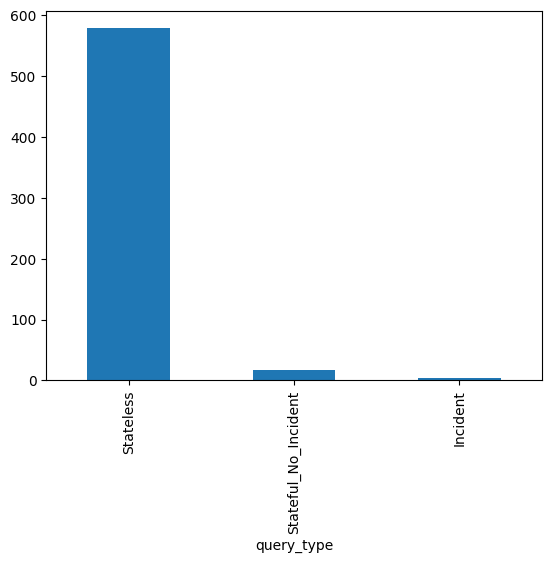

In [3]:
orig_df["query_type"] = orig_df.apply(
  lambda row: classify_question(row["query"], row.get("sql_query")), axis=1
)
print(orig_df["query_type"].value_counts())
print((orig_df["query_type"].value_counts() / len(orig_df)) * 100)
orig_df["query_type"].value_counts().plot(kind="bar")

In [4]:
inc_qs = orig_df[orig_df["query_type"] == "Incident"]["query"].tolist()
print(inc_qs)

['I need an overall risk rating for our trades. For each trade, calculate a composite score by averaging its suspicious activity index and its pattern anomaly score. Show me the 10 trades with the highest scores, along with their record key and the score itself.', "I'm curious if some hospitals are more willing to take a chance on a less-than-perfect genetic match.\nFor every transplant center that has performed at least two transplants, can you calculate their average HLA Mismatch Score?\nAlso, for each of those centers, figure out the standard deviation so we can see if their mismatch numbers are all over the place or pretty consistent.\nThen, just show me the top 10 from that group with the highest average mismatch scores.\nI'll need to see their total number of transplants, that average mismatch score rounded to four decimals, and the standard deviation, also rounded to four decimals.", "I'm trying to figure out our data storage plan. Can you analyze the environmental readings for 

In [ ]:
orig_df.to_csv("birdlivesql_data_classified.csv", index=False)